## Crack Segmentation
Goal: train a fully convolutional segmentation model (U-Net) that maps an input image to a binary crack mask.
Important rule: do not use the test/ set for training (we only run inference on it). 


Done in pair by Dariia Shevchuk 161200 and Maryia Pisaryk 161190. 

### Environment setup and imports

In [15]:
!pip -q install albumentations opencv-python tqdm scikit-learn


In [16]:
import os
from pathlib import Path
import random
import numpy as np
import cv2
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split


### Reproducibility & configuration
- Fix random seeds for repeatable results.
- Centralize key hyperparameters (image size, batch size, learning rate, epochs, validation split).

In [17]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CFG = {
    "img_size": 256,
    "batch_size": 8,
    "num_workers": 8,
    "lr": 3e-4,
    "epochs": 5,
    "val_size": 0.2,
}


### Automatically locate the dataset folder and verify that train/test directories exist before training.

In [18]:
def find_dataset_dir(target_name="crack_segmentation_dataset"):
    here = Path.cwd()
    candidates = [
        here / target_name,
        here.parent / target_name,
        Path("/content") / target_name,
        Path("/mnt/data") / target_name,
    ]
    for c in candidates:
        if c.exists() and c.is_dir():
            return c
    for p in [here, here.parent, here.parent.parent]:
        for c in p.rglob(target_name):
            if c.is_dir():
                return c
    raise FileNotFoundError(f"Could not find folder '{target_name}' in common locations.")

DATA_DIR = find_dataset_dir("crack_segmentation_dataset")
TRAIN_IMG_DIR = DATA_DIR / "train" / "images"
TRAIN_MSK_DIR = DATA_DIR / "train" / "masks"
TEST_IMG_DIR  = DATA_DIR / "test" / "images"

print("DATA_DIR:", DATA_DIR)
print("Train images:", TRAIN_IMG_DIR, "exists:", TRAIN_IMG_DIR.exists())
print("Train masks :", TRAIN_MSK_DIR, "exists:", TRAIN_MSK_DIR.exists())
print("Test images :", TEST_IMG_DIR,  "exists:", TEST_IMG_DIR.exists())


DATA_DIR: /home/chupakabra/DL/cnn_project/crack_segmentation_dataset
Train images: /home/chupakabra/DL/cnn_project/crack_segmentation_dataset/train/images exists: True
Train masks : /home/chupakabra/DL/cnn_project/crack_segmentation_dataset/train/masks exists: True
Test images : /home/chupakabra/DL/cnn_project/crack_segmentation_dataset/test/images exists: True


### Pairing images with ground-truth masks

In [19]:
def list_images(folder: Path):
    exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])

train_imgs = list_images(TRAIN_IMG_DIR)
train_msks = list_images(TRAIN_MSK_DIR)

print("Train images:", len(train_imgs))
print("Train masks :", len(train_msks))

msk_map = {p.stem: p for p in train_msks}
pairs = []
missing = 0
for img_p in train_imgs:
    m = msk_map.get(img_p.stem, None)
    if m is None:
        missing += 1
    else:
        pairs.append((img_p, m))

print("Paired:", len(pairs), "| Missing masks:", missing)
assert len(pairs) > 0, "No (image, mask) pairs found. Check filenames / folders."


Train images: 9603
Train masks : 9603
Paired: 9603 | Missing masks: 0


### Quick visualization and sanity check

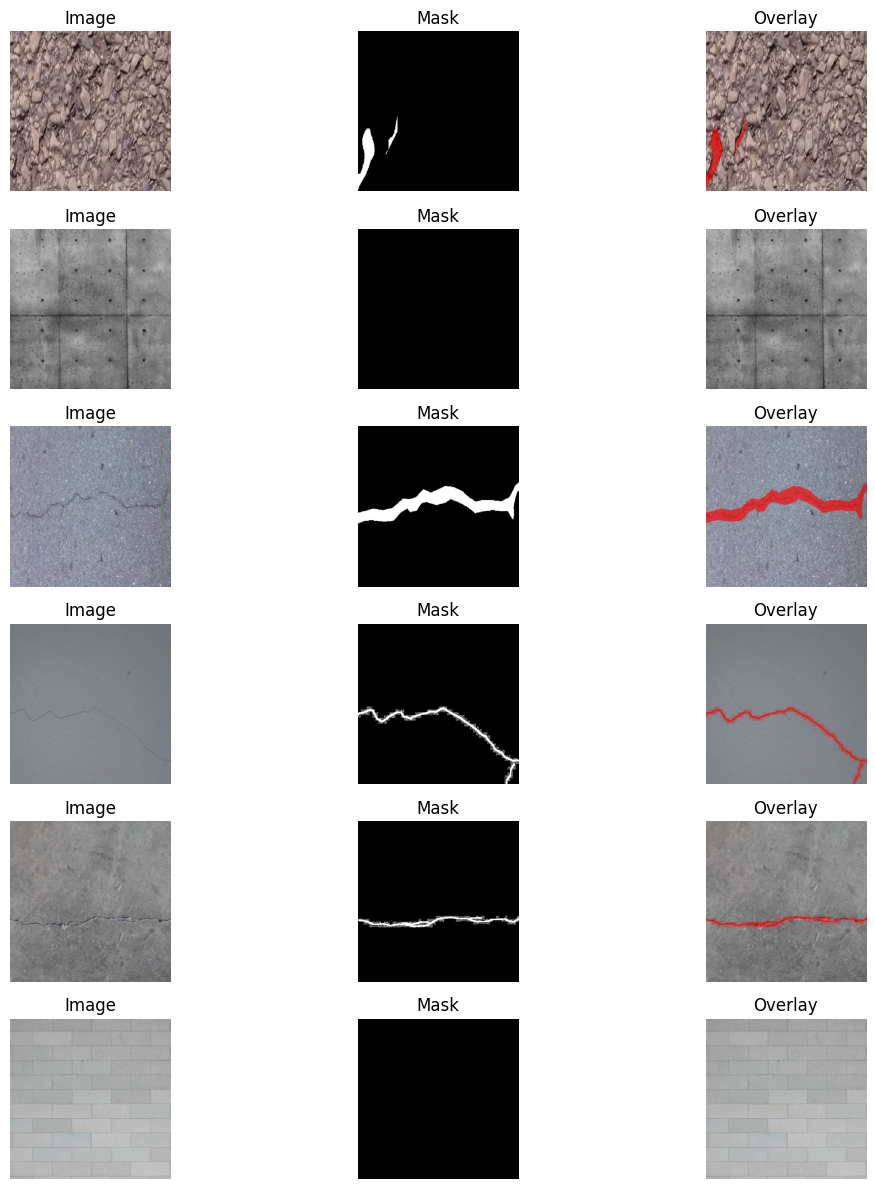

In [20]:
import matplotlib.pyplot as plt

def show_samples(pairs, n=6):
    idxs = np.random.choice(len(pairs), size=min(n, len(pairs)), replace=False)
    plt.figure(figsize=(12, 2*len(idxs)))
    for i, k in enumerate(idxs):
        img_p, msk_p = pairs[k]
        img = cv2.cvtColor(cv2.imread(str(img_p)), cv2.COLOR_BGR2RGB)
        msk = cv2.imread(str(msk_p), cv2.IMREAD_GRAYSCALE)
        msk_bin = (msk > 127).astype(np.uint8)

        overlay = img.copy()
        overlay[msk_bin == 1] = (overlay[msk_bin == 1] * 0.35 + np.array([255, 0, 0]) * 0.65).astype(np.uint8)

        plt.subplot(len(idxs), 3, 3*i+1); plt.imshow(img); plt.axis("off"); plt.title("Image")
        plt.subplot(len(idxs), 3, 3*i+2); plt.imshow(msk_bin, cmap="gray"); plt.axis("off"); plt.title("Mask")
        plt.subplot(len(idxs), 3, 3*i+3); plt.imshow(overlay); plt.axis("off"); plt.title("Overlay")
    plt.tight_layout()
    plt.show()

show_samples(pairs, n=6)


### Train/validation split

In [21]:
train_pairs, val_pairs = train_test_split(pairs, test_size=CFG["val_size"], random_state=SEED, shuffle=True)
print("Train:", len(train_pairs), "Val:", len(val_pairs))


Train: 7682 Val: 1921


### Augmentations and normalization

- Use flips/rotations/brightness changes to improve robustness.
- Normalize inputs to stabilize training (consistent scale helps optimization).

In [22]:
IMG_SIZE = CFG["img_size"]

train_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.12, rotate_limit=15, border_mode=cv2.BORDER_REFLECT_101, p=0.7),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

val_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])


/home/chupakabra/DL/cnn_project/venv/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### Data pipeline

Custom Dataset reads RGB images and binary masks, applies the same geometric transforms to both.
DataLoader batches data for GPU training and faster iteration.

In [23]:
class CrackSegDataset(Dataset):
    def __init__(self, pairs, tfms):
        self.pairs = pairs
        self.tfms = tfms

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_p, msk_p = self.pairs[idx]
        img = cv2.cvtColor(cv2.imread(str(img_p)), cv2.COLOR_BGR2RGB)
        msk = cv2.imread(str(msk_p), cv2.IMREAD_GRAYSCALE)
        msk = (msk > 127).astype(np.float32)

        aug = self.tfms(image=img, mask=msk)
        x = aug["image"]
        y = aug["mask"].unsqueeze(0)
        return x, y

train_ds = CrackSegDataset(train_pairs, train_tfms)
val_ds   = CrackSegDataset(val_pairs, val_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape, xb.dtype, yb.dtype)


torch.Size([8, 3, 256, 256]) torch.Size([8, 1, 256, 256]) torch.float32 torch.float32


### Model: U-Net (fully convolutional segmentation)

U-Net is a standard fully convolutional architecture for segmentation:
contracting path (context) + expanding path (localization) + skip connections. 


In [24]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x):
        return self.conv(self.pool(x))

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        dy = x2.size(2) - x1.size(2)
        dx = x2.size(3) - x1.size(3)
        x1 = F.pad(x1, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base=32):
        super().__init__()
        self.in_conv = DoubleConv(in_channels, base)
        self.down1 = Down(base, base*2)
        self.down2 = Down(base*2, base*4)
        self.down3 = Down(base*4, base*8)
        self.down4 = Down(base*8, base*16)

        self.up1 = Up(base*16, base*8)
        self.up2 = Up(base*8, base*4)
        self.up3 = Up(base*4, base*2)
        self.up4 = Up(base*2, base)

        self.out_conv = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.in_conv(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x,  x3)
        x = self.up3(x,  x2)
        x = self.up4(x,  x1)
        return self.out_conv(x)

model = UNet(base=16).to(DEVICE)
sum(p.numel() for p in model.parameters()) / 1e6


1.942577

### Loss and evaluation metrics

Optimize a combination of BCEWithLogits (stable binary segmentation loss) and soft Dice loss (handles class imbalance).
Track IoU (main segmentation metric) and Dice during validation.

In [25]:
def dice_coef_from_logits(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    probs = (probs > 0.5).float()
    targets = (targets > 0.5).float()
    inter = (probs * targets).sum(dim=(2,3))
    union = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3))
    dice = (2*inter + eps) / (union + eps)
    return dice.mean()

def iou_from_logits(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    probs = (probs > 0.5).float()
    targets = (targets > 0.5).float()
    inter = (probs * targets).sum(dim=(2,3))
    union = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) - inter
    iou = (inter + eps) / (union + eps)
    return iou.mean()

def soft_dice_loss(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    targets = targets.float()
    inter = (probs * targets).sum(dim=(2,3))
    union = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3))
    dice = (2*inter + eps) / (union + eps)
    return 1 - dice.mean()

bce = nn.BCEWithLogitsLoss()

def loss_fn(logits, targets):
    return 0.5 * bce(logits, targets) + 0.5 * soft_dice_loss(logits, targets)


### Training loop (mini-batches + validation)

Standard training cycle: forward -> loss -> backprop -> optimizer step; repeated for each epoch. 
Save the best model checkpoint based on validation IoU.

In [26]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    for x, y in tqdm(loader, leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
            logits = model(x)
            loss = loss_fn(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    for x, y in tqdm(loader, leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        d = dice_coef_from_logits(logits, y).item()
        j = iou_from_logits(logits, y).item()
        total_loss += loss.item() * x.size(0)
        total_dice += d * x.size(0)
        total_iou  += j * x.size(0)
    n = len(loader.dataset)
    return total_loss / n, total_dice / n, total_iou / n


/tmp/ipykernel_17360/3701367090.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))


In [27]:
best_iou = -1
best_path = Path("best_unet.pt")

history = []
for epoch in range(1, CFG["epochs"] + 1):
    tr_loss = train_one_epoch(model, train_loader)
    va_loss, va_dice, va_iou = eval_one_epoch(model, val_loader)

    scheduler.step(va_iou)

    if va_iou > best_iou:
        best_iou = va_iou
        torch.save(model.state_dict(), best_path)

    history.append((epoch, tr_loss, va_loss, va_dice, va_iou, optimizer.param_groups[0]["lr"]))
    print(f"Epoch {epoch:03d} | tr_loss {tr_loss:.4f} | va_loss {va_loss:.4f} | dice {va_dice:.4f} | iou {va_iou:.4f} | best_iou {best_iou:.4f}")


  0%|          | 0/961 [00:00<?, ?it/s]/tmp/ipykernel_17360/3701367090.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):


Epoch 001 | tr_loss 0.5611 | va_loss 0.3998 | dice 0.5132 | iou 0.3845 | best_iou 0.3845


Epoch 002 | tr_loss 0.3613 | va_loss 0.3076 | dice 0.5465 | iou 0.4167 | best_iou 0.4167


Epoch 003 | tr_loss 0.3158 | va_loss 0.2957 | dice 0.5503 | iou 0.4183 | best_iou 0.4183


Epoch 004 | tr_loss 0.3070 | va_loss 0.2858 | dice 0.5613 | iou 0.4317 | best_iou 0.4317


Epoch 005 | tr_loss 0.3008 | va_loss 0.2824 | dice 0.5788 | iou 0.4489 | best_iou 0.4489


### Learning curves

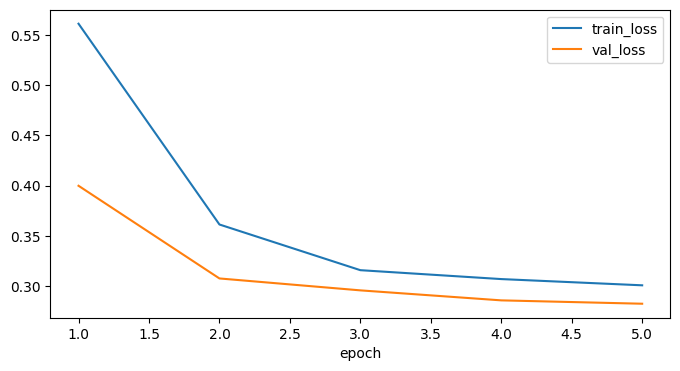

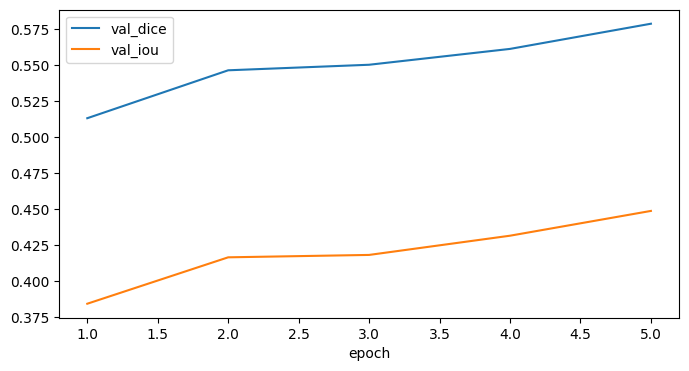

In [28]:
import matplotlib.pyplot as plt

epochs = [h[0] for h in history]
tr_loss = [h[1] for h in history]
va_loss = [h[2] for h in history]
va_dice = [h[3] for h in history]
va_iou  = [h[4] for h in history]

plt.figure(figsize=(8,4))
plt.plot(epochs, tr_loss, label="train_loss")
plt.plot(epochs, va_loss, label="val_loss")
plt.legend()
plt.xlabel("epoch")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(epochs, va_dice, label="val_dice")
plt.plot(epochs, va_iou, label="val_iou")
plt.legend()
plt.xlabel("epoch")
plt.show()


### Visualize predicted masks next to ground truth to confirm the model segments crack shapes correctly (not only good metrics).

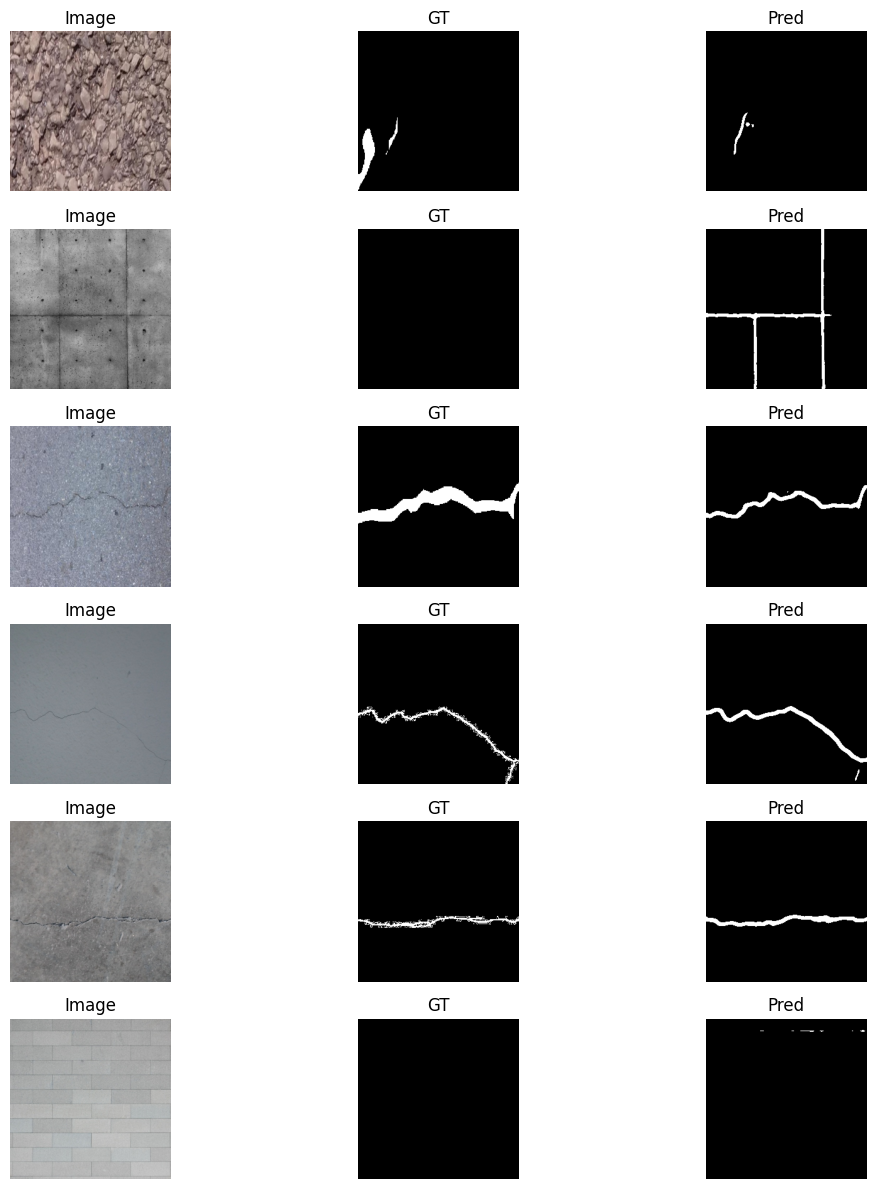

In [29]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

def predict_batch(x):
    with torch.no_grad():
        logits = model(x.to(DEVICE))
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs

xb, yb = next(iter(val_loader))
probs = predict_batch(xb)
pred = (probs > 0.5).astype(np.uint8)

n = min(6, xb.size(0))
plt.figure(figsize=(12, 2*n))
for i in range(n):
    img = xb[i].permute(1,2,0).numpy()
    img = (img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]))
    img = np.clip(img, 0, 1)

    gt = yb[i,0].numpy().astype(np.uint8)
    pr = pred[i,0]

    plt.subplot(n,3,3*i+1); plt.imshow(img); plt.axis("off"); plt.title("Image")
    plt.subplot(n,3,3*i+2); plt.imshow(gt, cmap="gray"); plt.axis("off"); plt.title("GT")
    plt.subplot(n,3,3*i+3); plt.imshow(pr, cmap="gray"); plt.axis("off"); plt.title("Pred")
plt.tight_layout()
plt.show()


### Run the trained model on test/images, threshold probabilities to a binary mask, and save masks as PNG files.

In [30]:
test_imgs = list_images(TEST_IMG_DIR)
print("Test images:", len(test_imgs))

test_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

def preprocess_test(img_path):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    aug = test_tfms(image=img)
    return aug["image"], img.shape[:2]

@torch.no_grad()
def predict_single(img_t):
    logits = model(img_t.unsqueeze(0).to(DEVICE))
    prob = torch.sigmoid(logits).squeeze(0).squeeze(0).cpu().numpy()
    return prob

PRED_DIR = Path("pred_masks_png")
PRED_DIR.mkdir(parents=True, exist_ok=True)

for p in tqdm(test_imgs):
    x, (h0, w0) = preprocess_test(p)
    prob = predict_single(x)
    mask = (prob > 0.5).astype(np.uint8) * 255
    mask = cv2.resize(mask, (w0, h0), interpolation=cv2.INTER_NEAREST)
    cv2.imwrite(str(PRED_DIR / f"{p.stem}.png"), mask)


Test images: 1695


100%|██████████| 1695/1695 [01:40<00:00, 16.89it/s]


### Prepare the submission.csv

In [ ]:
import pandas as pd
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm

PRED_DIR = Path("pred_masks_png")

def mask2rle(img01):
    pixels = img01.T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(str(x) for x in runs)

pred_paths = sorted(PRED_DIR.glob("*.png"))
assert len(pred_paths) > 0, f"No predicted masks found in {PRED_DIR}"

rows = []
for p in tqdm(pred_paths, desc="Building submission"):
    m = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    m01 = (m > 127).astype(np.uint8)
    rle = mask2rle(m01)

    rows.append({
        "file": p.name,   
        "crack": rle     
    })

sub = pd.DataFrame(rows)
sub["crack"] = sub["crack"].fillna("")
sub.to_csv("submission.csv", index=False)

print("Saved submission.csv")
print(sub.head())
print("Shape:", sub.shape)


Building submission: 100%|██████████| 1695/1695 [00:03<00:00, 478.37it/s]


Saved submission.csv
          file                                              crack
0  CFD_001.png  232 13 680 13 1128 14 1576 14 2026 12 2474 12 ...
1  CFD_007.png  280 14 728 14 1174 16 1622 16 2070 14 2518 14 ...
2  CFD_011.png  175 7 623 7 1071 7 1519 7 1967 7 2415 7 2863 7...
3  CFD_013.png  257 16 705 16 1153 16 1601 16 2047 18 2495 18 ...
4  CFD_014.png  252 12 700 12 1148 12 1596 12 2044 12 2492 12 ...
Shape: (1695, 2)


In [9]:
TEST_IMG_DIR = Path("crack_segmentation_dataset/test/images")
test_imgs = sorted([p for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() in [".png",".jpg",".jpeg",".bmp",".tif",".tiff"]])

rows = []
for img_path in tqdm(test_imgs, desc="Building submission"):
    pred_mask_path = PRED_DIR / f"{img_path.stem}.png"
    if not pred_mask_path.exists():
        raise FileNotFoundError(f"Missing predicted mask: {pred_mask_path}")

    m = cv2.imread(str(pred_mask_path), cv2.IMREAD_GRAYSCALE)
    m01 = (m > 127).astype(np.uint8)
    rle = mask2rle(m01)

    rows.append({"file": img_path.name, "crack": rle})

sub = pd.DataFrame(rows)
sub["crack"] = sub["crack"].fillna("")
sub.to_csv("submission.csv", index=False)

print("Saved submission.csv")
print(sub.head())
print("Shape:", sub.shape)


Building submission: 100%|██████████| 1695/1695 [00:03<00:00, 479.20it/s]


Saved submission.csv
          file                                              crack
0  CFD_001.jpg  232 13 680 13 1128 14 1576 14 2026 12 2474 12 ...
1  CFD_007.jpg  280 14 728 14 1174 16 1622 16 2070 14 2518 14 ...
2  CFD_011.jpg  175 7 623 7 1071 7 1519 7 1967 7 2415 7 2863 7...
3  CFD_013.jpg  257 16 705 16 1153 16 1601 16 2047 18 2495 18 ...
4  CFD_014.jpg  252 12 700 12 1148 12 1596 12 2044 12 2492 12 ...
Shape: (1695, 2)


In [ ]:
sub = pd.read_csv("submission.csv", keep_default_na=False)
assert list(sub.columns) == ["file", "crack"]
assert len(sub) > 0
print("✅ Columns OK:", sub.columns.tolist(), "rows:", len(sub))


✅ Columns OK: ['file', 'crack'] rows: 1695


### Conclusion

In this project we implemented a full crack segmentation pipeline. We prepared the dataset as image mask pairs, applied consistent augmentations and normalization, and trained a U-Net encoder decoder model with skip connections to predict pixel-level crack masks. To handle strong class imbalance (thin cracks vs background), we combined BCE with Dice loss and evaluated the model using Dice and IoU on a validation split. Finally, we generated masks for the test set and prepared a submission file. The results show that the model can accurately localize crack regions (score 0.600424
 on Kaggle, submitted by Dariia Shevchuk), and performance could be further improved by tuning thresholds/post-processing and trying stronger backbones higher resolution training.